# ODSB-17073 Follow-Up: Daily Creative Format Mix Analysis

**Ticket**: ODSB-17073 | **Campaign**: `QRrtrBKKVcZzcKni` | **Platform**: `HANSSEMCOLTD`  
**Objective**: Understand daily creative format mix shifts and their drivers (TCM divergence, budget changes, ad group changes, bidfloor dynamics)  
**Date Range**: 2025-12-08 to 2026-03-18  
**Prior Finding**: CPM volatility = Simpson's Paradox in format mix. This notebook investigates *why* format mix shifts day-to-day.

## Setup

In [22]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

client = bigquery.Client(project='moloco-ods')

def run_query(query, label=''):
    df = client.query(query).result().to_dataframe()
    print(f'✅ {label}: {len(df)} rows')
    return df

CAMPAIGN_ID = 'QRrtrBKKVcZzcKni'
PLATFORM_ID = 'HANSSEMCOLTD'
START_DATE = '2025-12-08'
END_DATE   = '2026-03-18'

# Key event dates for annotation
EVENTS = {
    '2025-12-31': 'AG1 disabled',
    '2026-01-26': 'INCIDENT-268',
    '2026-01-27': 'CPM spike',
    '2026-02-02': 'AG2 disabled',
    '2026-02-26': 'New AG created',
    '2026-03-03': 'New AG enabled',
}

# Format color palette — distinct hues across the spectrum
FORMAT_COLORS = {
    'ni': '#2196F3',   # native — vivid blue
    'ib': '#FF9800',   # banner — orange
    'nv': '#9C27B0',   # native video — purple
    'nl': '#4CAF50',   # native large — green
    'vi': '#F44336',   # video interstitial — red (expensive)
    'ii': '#795548',   # image interstitial — brown (expensive)
}

## Section 0 — Daily Format Mix: Full Period

In [23]:
q0 = f"""
SELECT
    DATE(timestamp_utc) AS date_utc,
    creative.format AS cr_format,
    SUM(impressions) AS impressions,
    SUM(gross_spend_usd) AS spend_usd,
    SAFE_DIVIDE(SUM(gross_spend_usd), SUM(impressions)) * 1000 AS cpm
FROM `moloco-ae-view.athena.fact_dsp_all`
WHERE campaign_id = '{CAMPAIGN_ID}'
  AND platform_id = '{PLATFORM_ID}'
  AND DATE(timestamp_utc) BETWEEN '{START_DATE}' AND '{END_DATE}'
GROUP BY date_utc, cr_format
ORDER BY date_utc, cr_format
"""
df0 = run_query(q0, 'Daily format mix')
df0['date_utc'] = pd.to_datetime(df0['date_utc'])
df0.head()

✅ Daily format mix: 707 rows


,date_utc,cr_format,impressions,spend_usd,cpm
0,2025-12-08,ib,12632,6.376580107,0.504796000
1,2025-12-08,ii,4550,4.865893878,1.069427000
2,2025-12-08,ni,28686,21.216209147,0.739602000
3,2025-12-08,nl,3882,0.126420547,0.032566000
4,2025-12-08,nv,36,0.000657915,0.018275000


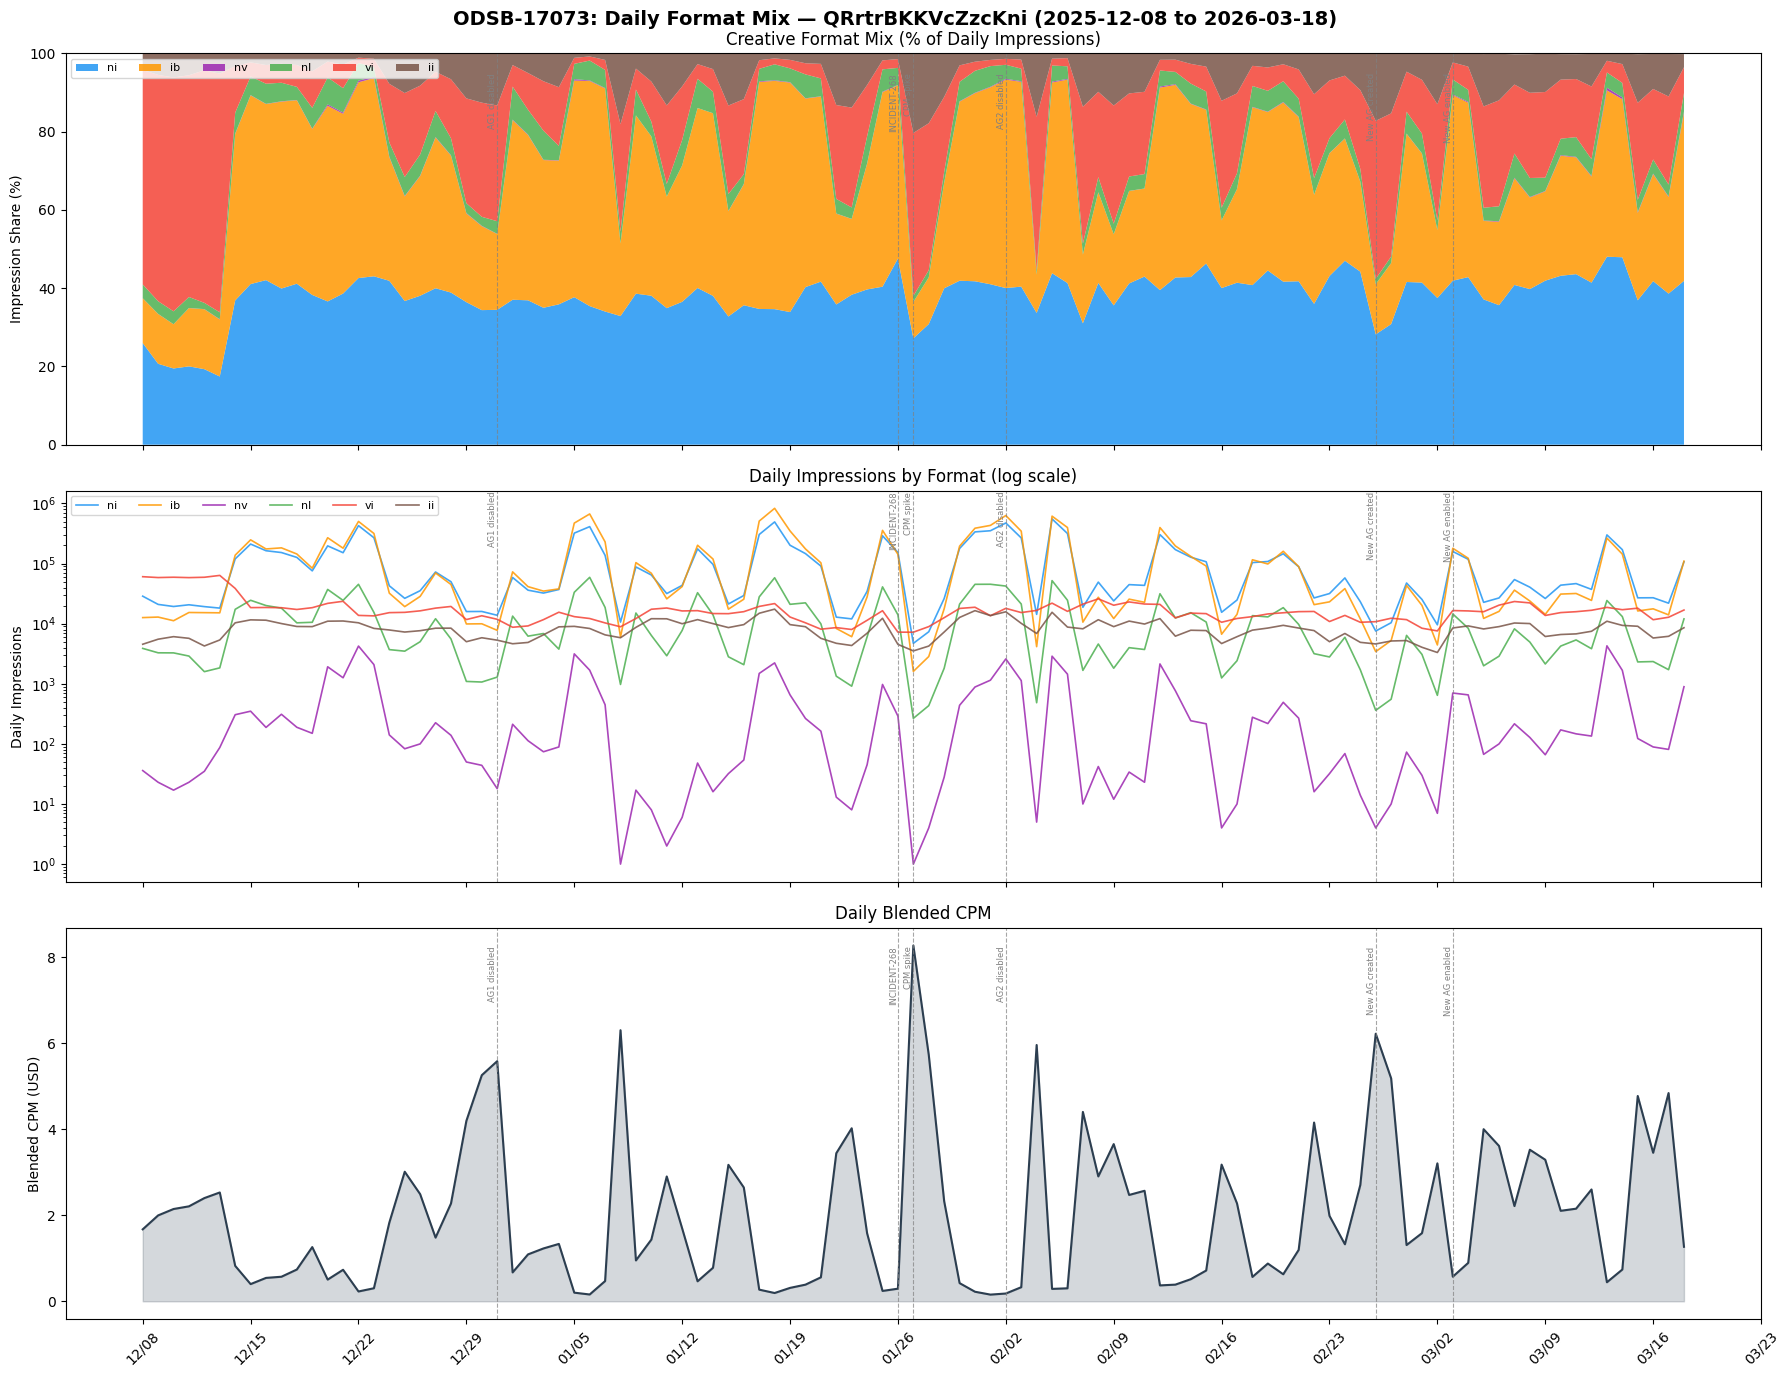

Saved: ODSB-17073_daily_format_mix.png


In [24]:
# Pivot for stacked area chart
pivot_imp = df0.pivot_table(index='date_utc', columns='cr_format', values='impressions', fill_value=0)
pivot_imp_pct = pivot_imp.div(pivot_imp.sum(axis=1), axis=0) * 100

# Daily blended CPM — use plain float scalar, not np.where (which returns 0-d array → object dtype)
daily_cpm = df0.groupby('date_utc').apply(
    lambda x: x['spend_usd'].sum() / x['impressions'].sum() * 1000
              if x['impressions'].sum() > 0 else np.nan
).reset_index()
daily_cpm.columns = ['date_utc', 'blended_cpm']
daily_cpm['date_utc'] = pd.to_datetime(daily_cpm['date_utc'])
daily_cpm['blended_cpm'] = daily_cpm['blended_cpm'].astype(float)

# Daily total impressions
daily_total = df0.groupby('date_utc')['impressions'].sum().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)
fig.suptitle(f'ODSB-17073: Daily Format Mix — {CAMPAIGN_ID} ({START_DATE} to {END_DATE})',
             fontsize=14, fontweight='bold')

# Panel 1: Stacked area (impression %)
ax1 = axes[0]
formats_ordered = [f for f in ['ni', 'ib', 'nv', 'nl', 'vi', 'ii'] if f in pivot_imp_pct.columns]
colors = [FORMAT_COLORS.get(f, '#95a5a6') for f in formats_ordered]
ax1.stackplot(pivot_imp_pct.index, [pivot_imp_pct[f] for f in formats_ordered],
              labels=formats_ordered, colors=colors, alpha=0.85)
ax1.set_ylabel('Impression Share (%)')
ax1.set_ylim(0, 100)
ax1.legend(loc='upper left', ncol=6, fontsize=8)
ax1.set_title('Creative Format Mix (% of Daily Impressions)')

# Panel 2: Daily impression volume by format (log scale)
ax2 = axes[1]
for fmt in formats_ordered:
    if fmt in pivot_imp.columns:
        ax2.plot(pivot_imp.index, pivot_imp[fmt],
                 label=fmt, color=FORMAT_COLORS.get(fmt, '#95a5a6'),
                 linewidth=1.2, alpha=0.85)
ax2.set_ylabel('Daily Impressions')
ax2.set_yscale('log')
ax2.legend(loc='upper left', ncol=6, fontsize=8)
ax2.set_title('Daily Impressions by Format (log scale)')

# Panel 3: Blended CPM
ax3 = axes[2]
x_num = mdates.date2num(daily_cpm['date_utc'])
ax3.plot(x_num, daily_cpm['blended_cpm'], color='#2c3e50', linewidth=1.5)
ax3.fill_between(x_num, daily_cpm['blended_cpm'], alpha=0.2, color='#2c3e50')
ax3.set_ylabel('Blended CPM (USD)')
ax3.set_title('Daily Blended CPM')

# Annotate key events on all panels
for ax in axes:
    for date_str, label in EVENTS.items():
        dt = pd.to_datetime(date_str)
        ax.axvline(x=dt, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.text(dt, ax.get_ylim()[1] * 0.95, label, fontsize=6, rotation=90,
                ha='right', va='top', color='gray')

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax3.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ODSB-17073_daily_format_mix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ODSB-17073_daily_format_mix.png')

## Section 1 — Day-of-Week Pattern by Format

✅ DOW x format: 49 rows


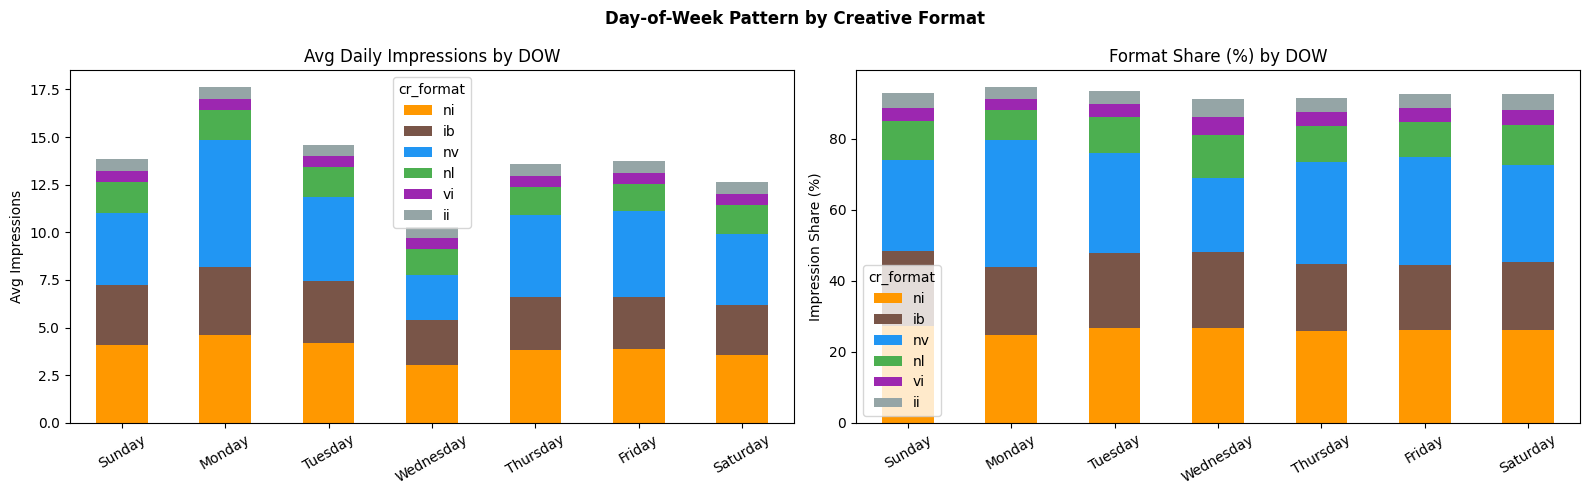

In [25]:
q1 = f"""
SELECT
    FORMAT_DATE('%A', DATE(timestamp_utc)) AS day_of_week,
    EXTRACT(DAYOFWEEK FROM DATE(timestamp_utc)) AS dow_num,
    creative.format AS cr_format,
    AVG(impressions) AS avg_daily_impressions,
    SAFE_DIVIDE(SUM(gross_spend_usd), SUM(impressions)) * 1000 AS avg_cpm
FROM (
    SELECT DATE(timestamp_utc) AS date_utc, timestamp_utc,
           creative, impressions, gross_spend_usd
    FROM `moloco-ae-view.athena.fact_dsp_all`
    WHERE campaign_id = '{CAMPAIGN_ID}'
      AND platform_id = '{PLATFORM_ID}'
      AND DATE(timestamp_utc) BETWEEN '{START_DATE}' AND '{END_DATE}'
)
GROUP BY day_of_week, dow_num, creative.format
ORDER BY dow_num, cr_format
"""
df1 = run_query(q1, 'DOW x format')

# Pivot and plot
dow_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
pivot_dow = df1.pivot_table(index='day_of_week', columns='cr_format',
                             values='avg_daily_impressions', fill_value=0)
pivot_dow = pivot_dow.reindex([d for d in dow_order if d in pivot_dow.index])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Day-of-Week Pattern by Creative Format', fontweight='bold')

# Stacked bar: avg impressions by DOW
pivot_dow[[f for f in ['ni','ib','nv','nl','vi','ii'] if f in pivot_dow.columns]].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[FORMAT_COLORS.get(f,'#95a5a6') for f in pivot_dow.columns])
axes[0].set_title('Avg Daily Impressions by DOW')
axes[0].set_xlabel('')
axes[0].set_ylabel('Avg Impressions')
axes[0].tick_params(axis='x', rotation=30)

# Format share by DOW
pivot_dow_pct = pivot_dow.div(pivot_dow.sum(axis=1), axis=0) * 100
pivot_dow_pct[[f for f in ['ni','ib','nv','nl','vi','ii'] if f in pivot_dow_pct.columns]].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[FORMAT_COLORS.get(f,'#95a5a6') for f in pivot_dow_pct.columns])
axes[1].set_title('Format Share (%) by DOW')
axes[1].set_xlabel('')
axes[1].set_ylabel('Impression Share (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('ODSB-17073_dow_format.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 2 — TCM Daily Trend × Per-Format Bid CPM

**Corrected framing**: TCM (Budget Multiplier) is a **single campaign-level scalar** updated every ~5 min by the budget pacer — it does NOT vary by `cr_format` or exchange within the same campaign. Grouping AVG(TCM) by format will show the same value across formats on the same day.

What *does* vary by format is `E[impression value]` (the model's predicted value per format), which drives the bid price. The correct hypothesis is:

> When TCM drops (budget constrained), `bid_price = E[value] × TCM × win-price-model` drops for **all** formats equally. But formats with low `E[value]` (ni, ib) may fall below bidfloor while vi (higher `E[value]`) stays above floor — shifting the mix toward vi.

This section shows:
- Panel 1: Campaign-level TCM over time (confirms it's a single shared value)
- Panel 2: Per-format avg bid CPM — the divergence here comes from `E[value]`, not TCM

✅ TCM + bid CPM by format daily: 687 rows


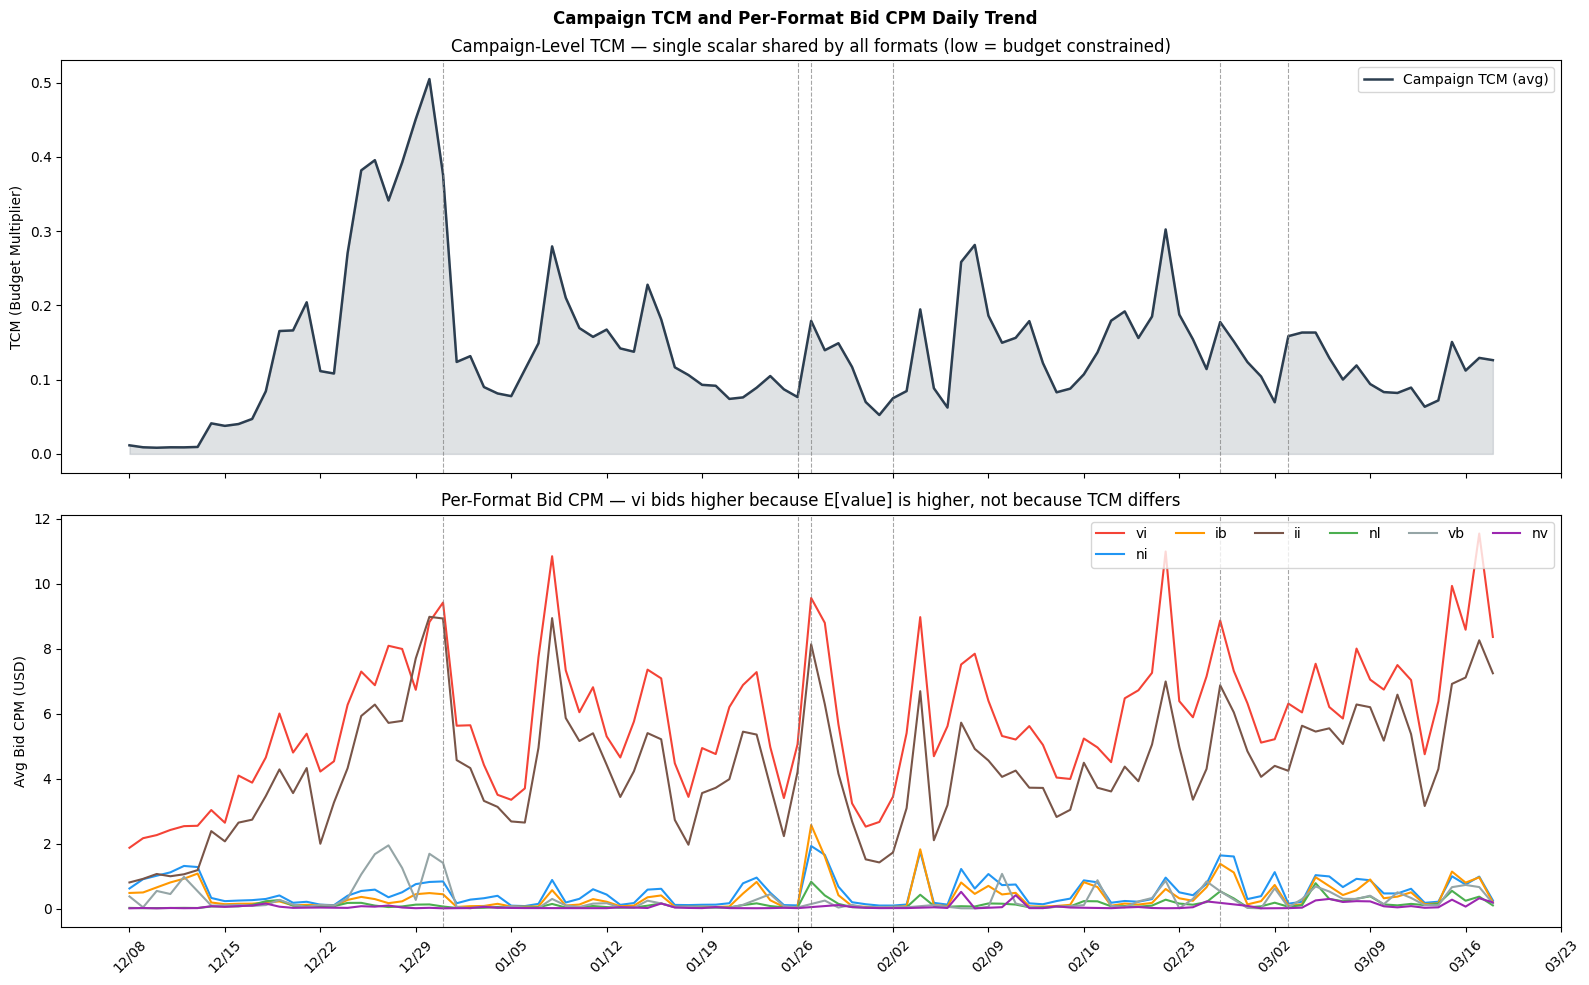

In [26]:
q2 = f"""
SELECT
    DATE(timestamp) AS date_utc,
    api.creative.cr_format,
    COUNT(*) * 10 AS est_impressions,
    ROUND(AVG(bid.MODEL.multipliers.budget), 6) AS avg_tcm,
    ROUND(AVG(bid.bid_price.amount_micro / 1e6) * 1000, 4) AS avg_bid_cpm,
    ROUND(AVG(SAFE_DIVIDE(bid.bid_price.amount_micro, req.imp.bidfloor.amount_micro)), 4) AS bid_to_floor_ratio
FROM `focal-elf-631.prod_stream_sampled.imp_1to10`
WHERE DATE(timestamp) BETWEEN '{START_DATE}' AND '{END_DATE}'
  AND api.campaign.id = '{CAMPAIGN_ID}'
GROUP BY 1, 2
ORDER BY 1, est_impressions DESC
"""
df2 = run_query(q2, 'TCM + bid CPM by format daily')
df2['date_utc'] = pd.to_datetime(df2['date_utc'])

# Campaign-level TCM: collapse to daily average (should be same across formats)
daily_tcm = df2.groupby('date_utc')['avg_tcm'].mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Campaign TCM and Per-Format Bid CPM Daily Trend', fontweight='bold')

# Panel 1: Campaign-level TCM (single line — TCM is format-agnostic)
axes[0].plot(daily_tcm['date_utc'], daily_tcm['avg_tcm'],
             color='#2c3e50', linewidth=1.8, label='Campaign TCM (avg)')
axes[0].fill_between(mdates.date2num(daily_tcm['date_utc']),
                     daily_tcm['avg_tcm'].astype(float),
                     alpha=0.15, color='#2c3e50')
axes[0].set_ylabel('TCM (Budget Multiplier)')
axes[0].set_title('Campaign-Level TCM — single scalar shared by all formats (low = budget constrained)')
axes[0].legend(loc='upper right')

# Panel 2: Per-format bid CPM — divergence here is E[value] difference, not TCM
for fmt in df2['cr_format'].unique():
    sub = df2[df2['cr_format'] == fmt].sort_values('date_utc')
    col = FORMAT_COLORS.get(fmt, '#95a5a6')
    axes[1].plot(sub['date_utc'], sub['avg_bid_cpm'], label=fmt, color=col, linewidth=1.5)

axes[1].set_ylabel('Avg Bid CPM (USD)')
axes[1].set_title('Per-Format Bid CPM — vi bids higher because E[value] is higher, not because TCM differs')
axes[1].legend(loc='upper right', ncol=6)

for ax in axes:
    for date_str, label in EVENTS.items():
        ax.axvline(x=pd.to_datetime(date_str), color='gray', linestyle='--',
                   linewidth=0.8, alpha=0.7)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ODSB-17073_tcm_by_format.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Ad Group Changes × Format Mix

Ad groups can be tied to specific creative formats. Disabling an ad group may remove all supply for a given format.

In [27]:
q3 = f"""
SELECT
    DATE(timestamp) AS change_date,
    TIMESTAMP_TRUNC(timestamp, HOUR) AS change_ts,
    JSON_VALUE(json_entity, '$.name') AS entity_name,
    entity_type,
    JSON_VALUE(json_entity, '$.enable') AS enabled,
    JSON_VALUE(json_entity, '$.campaign_id') AS campaign_id,
    JSON_QUERY(json_entity, '$.filter_expr') AS filter_expr
FROM `focal-elf-631.entity_history.prod_entity_history`
WHERE DATE(timestamp) BETWEEN '{START_DATE}' AND '{END_DATE}'
  AND entity_type = 'RTB_AD_GROUP'
  AND JSON_VALUE(json_entity, '$.campaign_id') = '{CAMPAIGN_ID}'
ORDER BY timestamp ASC
"""
df3 = run_query(q3, 'Ad group changes')
df3.head(20)

✅ Ad group changes: 0 rows


,change_date,change_ts,entity_name,entity_type,enabled,campaign_id,filter_expr


In [28]:
# Show unique ad groups and their enable/disable pattern
print("Ad group enable/disable timeline:")
print(df3[['change_date','entity_name','enabled']].drop_duplicates().to_string(index=False))

Ad group enable/disable timeline:
Empty DataFrame
Columns: [change_date, entity_name, enabled]
Index: []


## Section 4 — Budget Change × Format Mix Correlation

Hypothesis: Budget drops → higher throttling → lower TCM bids → ni/ib fall below bidfloor → only vi wins

In [29]:
q4 = f"""
WITH snapshots AS (
    SELECT
        DATE(timestamp) AS change_date,
        CAST(JSON_VALUE(json_entity, '$.capper.user_budget_enforcer.daily_budget') AS FLOAT64) AS daily_budget_krw
    FROM `focal-elf-631.entity_history.prod_entity_history`
    WHERE DATE(timestamp) BETWEEN '{START_DATE}' AND '{END_DATE}'
      AND entity_type = 'RTB_CAMPAIGN'
      AND JSON_VALUE(json_entity, '$.name') = '{CAMPAIGN_ID}'
),
with_prev AS (
    SELECT *,
           LAG(daily_budget_krw) OVER (ORDER BY change_date) AS prev_budget
    FROM snapshots
)
SELECT change_date,
       daily_budget_krw,
       prev_budget,
       ROUND(SAFE_DIVIDE(daily_budget_krw - prev_budget, prev_budget) * 100, 1) AS pct_change
FROM with_prev
WHERE daily_budget_krw != prev_budget OR prev_budget IS NULL
ORDER BY change_date
"""
df4_budget = run_query(q4, 'Budget changes')
df4_budget['change_date'] = pd.to_datetime(df4_budget['change_date'])
df4_budget

✅ Budget changes: 78 rows


,change_date,daily_budget_krw,prev_budget,pct_change
0,2025-12-08,340000.0,NaN,NaN
1,2025-12-08,340000.0,370000.0,-8.1
2,2025-12-08,370000.0,340000.0,8.8
3,2025-12-08,370000.0,340000.0,8.8
4,2025-12-23,344000.0,370000.0,-7.0
...,...,...,...,...
73,2026-03-17,452000.0,446000.0,1.3
74,2026-03-18,587000.0,507000.0,15.8
75,2026-03-18,515000.0,587000.0,-12.3
76,2026-03-18,587000.0,507000.0,15.8


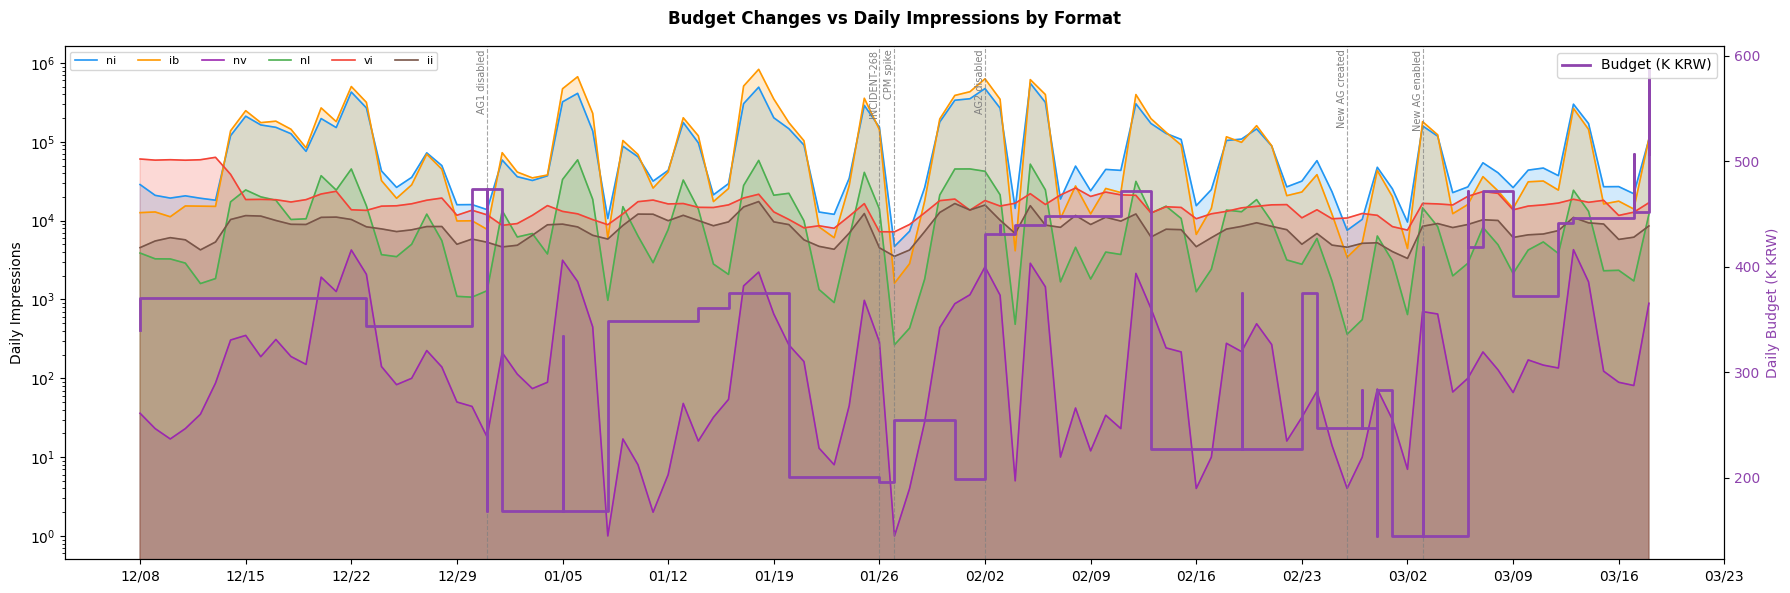

In [33]:
# Overlay budget changes with all-format impression trend
pivot_imp2 = df0.pivot_table(index='date_utc', columns='cr_format',
                              values='impressions', fill_value=0)

fig, ax1 = plt.subplots(figsize=(18, 6))
fig.suptitle('Budget Changes vs Daily Impressions by Format', fontweight='bold')

x_imp2 = mdates.date2num(pivot_imp2.index)
formats_ordered = [f for f in ['ni', 'ib', 'nv', 'nl', 'vi', 'ii'] if f in pivot_imp2.columns]

for fmt in formats_ordered:
    ax1.fill_between(x_imp2, pivot_imp2[fmt],
                     alpha=0.2, color=FORMAT_COLORS.get(fmt, '#95a5a6'))
    ax1.plot(x_imp2, pivot_imp2[fmt],
             color=FORMAT_COLORS.get(fmt, '#95a5a6'), linewidth=1.2, label=fmt)

ax1.set_ylabel('Daily Impressions')
ax1.set_yscale('log')
ax1.legend(loc='upper left', ncol=6, fontsize=8)

# Budget on secondary axis
ax2 = ax1.twinx()
ax2.step(df4_budget['change_date'], df4_budget['daily_budget_krw'] / 1000,
         color='#8e44ad', linewidth=2, where='post', label='Budget (K KRW)')
ax2.set_ylabel('Daily Budget (K KRW)', color='#8e44ad')
ax2.tick_params(axis='y', labelcolor='#8e44ad')
ax2.legend(loc='upper right')

# Annotate key events
for date_str, label in EVENTS.items():
    ax1.axvline(x=pd.to_datetime(date_str), color='gray', linestyle='--',
                linewidth=0.8, alpha=0.7)
    ax1.text(pd.to_datetime(date_str), ax1.get_ylim()[1] * 0.9, label,
             fontsize=7, rotation=90, ha='right', va='top', color='gray')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ODSB-17073_budget_vs_format.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 — Actual Spend vs Daily Impressions by Format

Spend share vs impression share by format — if vi has a disproportionately high spend share relative to its impression share, it is consuming budget at a higher CPM than other formats. Cross-referencing with budget changes shows which formats absorb spend when the budget is cut.

In [ ]:
pivot_spend = df0.pivot_table(index='date_utc', columns='cr_format', values='spend_usd', fill_value=0)
pivot_spend_pct = pivot_spend.div(pivot_spend.sum(axis=1), axis=0) * 100

formats_ordered = [f for f in ['ni', 'ib', 'nv', 'nl', 'vi', 'ii'] if f in pivot_imp.columns]
colors = [FORMAT_COLORS.get(f, '#95a5a6') for f in formats_ordered]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)
fig.suptitle('Actual Spend vs Impressions by Format — Daily', fontweight='bold')

# TL: Impression share (%)
ax = axes[0][0]
ax.stackplot(pivot_imp_pct.index,
             [pivot_imp_pct[f] for f in formats_ordered if f in pivot_imp_pct.columns],
             labels=formats_ordered, colors=colors, alpha=0.85)
ax.set_ylabel('Impression Share (%)')
ax.set_ylim(0, 100)
ax.set_title('Impression Share (%)')
ax.legend(loc='upper left', ncol=6, fontsize=7)

# TR: Spend share (%)
ax = axes[0][1]
ax.stackplot(pivot_spend_pct.index,
             [pivot_spend_pct[f] for f in formats_ordered if f in pivot_spend_pct.columns],
             labels=formats_ordered, colors=colors, alpha=0.85)
ax.set_ylabel('Spend Share (%)')
ax.set_ylim(0, 100)
ax.set_title('Spend Share (%)')
ax.legend(loc='upper left', ncol=6, fontsize=7)

# BL: Daily impressions by format (log)
ax = axes[1][0]
for fmt in formats_ordered:
    if fmt in pivot_imp.columns:
        ax.plot(pivot_imp.index, pivot_imp[fmt],
                color=FORMAT_COLORS.get(fmt, '#95a5a6'), linewidth=1.2, label=fmt)
ax.set_ylabel('Impressions')
ax.set_yscale('log')
ax.set_title('Daily Impressions by Format (log)')
ax.legend(loc='upper left', ncol=6, fontsize=7)

# BR: Daily spend by format (USD)
ax = axes[1][1]
for fmt in formats_ordered:
    if fmt in pivot_spend.columns:
        ax.plot(pivot_spend.index, pivot_spend[fmt],
                color=FORMAT_COLORS.get(fmt, '#95a5a6'), linewidth=1.2, label=fmt)
ax.set_ylabel('Spend (USD)')
ax.set_title('Daily Spend by Format (USD)')
ax.legend(loc='upper left', ncol=6, fontsize=7)

for ax_row in axes:
    for ax in ax_row:
        for date_str, label in EVENTS.items():
            ax.axvline(x=pd.to_datetime(date_str), color='gray', linestyle='--',
                       linewidth=0.8, alpha=0.7)

for ax in axes[1]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('ODSB-17073_spend_vs_imp_by_format.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ODSB-17073_spend_vs_imp_by_format.png')

## Section 6 — Bidfloor vs Bid CPM by Format

Check: when TCM is low (budget constrained), do ni/ib bids fall below bidfloor more often than vi? Since TCM is campaign-level, all formats are multiplied by the same scalar — but vi has higher `E[value]`, so its bid stays above floor while ni/ib bids drop below.

In [ ]:
q5 = f"""
SELECT
    DATE(timestamp) AS date_utc,
    api.creative.cr_format,
    COUNT(*) * 10 AS est_impressions,
    ROUND(AVG(req.imp.bidfloor.amount_micro / 1e6) * 1000, 4) AS avg_floor_cpm,
    ROUND(AVG(bid.bid_price.amount_micro / 1e6) * 1000, 4) AS avg_bid_cpm,
    ROUND(AVG(SAFE_DIVIDE(bid.bid_price.amount_micro, NULLIF(req.imp.bidfloor.amount_micro, 0))), 4)
        AS bid_floor_ratio,
    COUNTIF(bid.bid_price.amount_micro <= req.imp.bidfloor.amount_micro) AS at_or_below_floor_count
FROM `focal-elf-631.prod_stream_sampled.imp_1to10`
WHERE DATE(timestamp) BETWEEN '{START_DATE}' AND '{END_DATE}'
  AND api.campaign.id = '{CAMPAIGN_ID}'
GROUP BY 1, 2
ORDER BY 1, est_impressions DESC
"""
df5 = run_query(q5, 'Bidfloor by format')
df5['date_utc'] = pd.to_datetime(df5['date_utc'])

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Bid/Floor Ratio by Format — Lower = more likely to miss floor', fontweight='bold')

for fmt in df5['cr_format'].unique():
    sub = df5[df5['cr_format'] == fmt].sort_values('date_utc')
    col = FORMAT_COLORS.get(fmt, '#95a5a6')
    axes[0].plot(sub['date_utc'], sub['bid_floor_ratio'], label=fmt, color=col, linewidth=1.5)
    axes[1].plot(sub['date_utc'], sub['avg_floor_cpm'], label=f'{fmt} floor', color=col,
                 linewidth=1, linestyle='--')
    axes[1].plot(sub['date_utc'], sub['avg_bid_cpm'], label=f'{fmt} bid', color=col, linewidth=1.5)

axes[0].axhline(y=1.0, color='red', linestyle=':', linewidth=1, label='bid = floor')
axes[0].set_ylabel('Bid / Floor Ratio')
axes[0].set_title('Bid-to-Floor Ratio (< 1.0 = bid below floor = lost)')
axes[0].legend(loc='upper right', ncol=6, fontsize=8)
axes[1].set_ylabel('CPM (USD)')
axes[1].set_title('Avg Bid CPM vs Floor CPM by Format')
axes[1].legend(loc='upper right', ncol=6, fontsize=7)

for ax in axes:
    for date_str, label in EVENTS.items():
        ax.axvline(x=pd.to_datetime(date_str), color='gray', linestyle='--',
                   linewidth=0.8, alpha=0.7)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ODSB-17073_bidfloor_by_format.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Business Impact: Does CPM Fluctuation Hurt D1 Revenue?

**Hypothesis**: Format mix shifts drive CPM volatility. On vi-heavy days CPM is high but vi may deliver lower-quality re-engagement signals than ni/ib. Does D1 ROAS drop on high-CPM (vi-heavy) days?

- D1 revenue = attributed revenue within 1 day of impression (`cv.pb.attribution.reengagement = TRUE`)
- D1 ROAS = D1 revenue / spend
- If CPM ↑ but D1 ROAS ↓ → format mix shift is hurting efficiency, not just inflating cost

In [ ]:
q7 = f"""
WITH
spend AS (
  SELECT
    DATE(timestamp_utc)       AS date_utc,
    SUM(gross_spend_usd)      AS daily_spend_usd,
    SUM(impressions)          AS daily_impressions
  FROM `moloco-ae-view.athena.fact_dsp_all`
  WHERE campaign_id = '{CAMPAIGN_ID}'
    AND DATE(timestamp_utc) BETWEEN '{START_DATE}' AND '{END_DATE}'
  GROUP BY 1
),
d1_revenue AS (
  SELECT
    DATE(imp.happened_at)    AS date_utc,
    SUM(
      IF(
        TIMESTAMP_DIFF(cv.happened_at, imp.happened_at, DAY) < 1
          AND IFNULL(cv.revenue_usd.amount, 0) > 0,
        cv.revenue_usd.amount,
        0
      )
    ) AS d1_revenue_usd
  FROM `focal-elf-631.prod_stream_view.cv`
  WHERE api.campaign.id = '{CAMPAIGN_ID}'
    AND DATE(imp.happened_at) BETWEEN '{START_DATE}' AND DATE_ADD('{END_DATE}', INTERVAL 1 DAY)
    AND cv.pb.attribution.reengagement = TRUE
  GROUP BY 1
)
SELECT
  s.date_utc,
  s.daily_spend_usd,
  s.daily_impressions,
  SAFE_DIVIDE(s.daily_spend_usd, s.daily_impressions) * 1000  AS blended_cpm,
  IFNULL(r.d1_revenue_usd, 0)                                 AS d1_revenue_usd,
  SAFE_DIVIDE(IFNULL(r.d1_revenue_usd, 0), s.daily_spend_usd) AS d1_roas
FROM spend AS s
LEFT JOIN d1_revenue AS r ON s.date_utc = r.date_utc
ORDER BY s.date_utc
"""
df7 = run_query(q7, 'D1 ROAS vs CPM')
df7['date_utc'] = pd.to_datetime(df7['date_utc'])

print(f"\nDays with d1_revenue > 0: {(df7['d1_revenue_usd'] > 0).sum()} / {len(df7)}")
print(f"Avg D1 ROAS: {df7['d1_roas'].mean():.3f}")
print(f"Avg Blended CPM: ${df7['blended_cpm'].mean():.4f}")
df7.head()

In [ ]:
# Merge with format mix data
pivot_imp_pct7 = df0.pivot_table(index='date_utc', columns='cr_format',
                                  values='impressions', fill_value=0)
pivot_imp_pct7 = pivot_imp_pct7.div(pivot_imp_pct7.sum(axis=1), axis=0) * 100
df7_merged = df7.merge(
    pivot_imp_pct7.add_suffix('_pct').reset_index(),
    on='date_utc', how='left'
)

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)
fig.suptitle(f'ODSB-17073: Business Impact — CPM Fluctuation vs D1 Revenue ({START_DATE} to {END_DATE})',
             fontsize=13, fontweight='bold')

x7  = mdates.date2num(df7['date_utc'])
x7m = mdates.date2num(df7_merged['date_utc'])

# Panel 1: Blended CPM vs D1 ROAS (dual axis)
ax1 = axes[0]
color_cpm, color_roas = '#e74c3c', '#2980b9'
ax1.plot(x7, df7['blended_cpm'], color=color_cpm, linewidth=1.5)
ax1.fill_between(x7, df7['blended_cpm'].astype(float), alpha=0.15, color=color_cpm)
ax1.set_ylabel('Blended CPM (USD)', color=color_cpm)
ax1.tick_params(axis='y', labelcolor=color_cpm)
ax1r = ax1.twinx()
ax1r.plot(x7, df7['d1_roas'], color=color_roas, linewidth=1.5, linestyle='--')
ax1r.set_ylabel('D1 ROAS', color=color_roas)
ax1r.tick_params(axis='y', labelcolor=color_roas)
ax1.set_title('Blended CPM (red) vs D1 ROAS (blue dashed)')
ax1.legend(handles=[plt.Line2D([0],[0],color=color_cpm,linewidth=1.5,label='Blended CPM'),
                    plt.Line2D([0],[0],color=color_roas,linewidth=1.5,linestyle='--',label='D1 ROAS')],
           loc='upper left', fontsize=8)

# Panel 2: Daily spend vs D1 revenue
ax2 = axes[1]
color_spend, color_rev = '#8e44ad', '#27ae60'
ax2.bar(x7, df7['daily_spend_usd'], color=color_spend, alpha=0.5, width=0.8)
ax2.set_ylabel('Spend (USD)', color=color_spend)
ax2.tick_params(axis='y', labelcolor=color_spend)
ax2r = ax2.twinx()
ax2r.plot(x7, df7['d1_revenue_usd'], color=color_rev, linewidth=1.5)
ax2r.set_ylabel('D1 Revenue (USD)', color=color_rev)
ax2r.tick_params(axis='y', labelcolor=color_rev)
ax2.set_title('Daily Spend (bars) vs D1 Revenue')
ax2.legend(handles=[plt.Line2D([0],[0],color=color_spend,linewidth=8,alpha=0.5,label='Daily Spend'),
                    plt.Line2D([0],[0],color=color_rev,linewidth=1.5,label='D1 Revenue')],
           loc='upper left', fontsize=8)

# Panel 3: vi share vs D1 ROAS
ax3 = axes[2]
color_vi, color_roas2 = FORMAT_COLORS['vi'], '#2980b9'
if 'vi_pct' in df7_merged.columns:
    ax3.fill_between(x7m, df7_merged['vi_pct'].astype(float), alpha=0.3, color=color_vi)
    ax3.plot(x7m, df7_merged['vi_pct'], color=color_vi, linewidth=1)
ax3.set_ylabel('vi Impression Share (%)', color=color_vi)
ax3.tick_params(axis='y', labelcolor=color_vi)
ax3r = ax3.twinx()
ax3r.plot(x7m, df7_merged['d1_roas'], color=color_roas2, linewidth=1.5, linestyle='--')
ax3r.set_ylabel('D1 ROAS', color=color_roas2)
ax3r.tick_params(axis='y', labelcolor=color_roas2)
ax3.set_title('vi Share (red fill) vs D1 ROAS (blue dashed) — core hypothesis')
ax3.legend(handles=[plt.Line2D([0],[0],color=color_vi,linewidth=8,alpha=0.3,label='vi Share (%)'),
                    plt.Line2D([0],[0],color=color_roas2,linewidth=1.5,linestyle='--',label='D1 ROAS')],
           loc='upper left', fontsize=8)

for ax in axes:
    for date_str, label in EVENTS.items():
        ax.axvline(x=pd.to_datetime(date_str), color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax3.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ODSB-17073_business_impact_roas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ODSB-17073_business_impact_roas.png')

In [ ]:
# Correlation: CPM / format shares vs D1 ROAS
corr_cols = ['blended_cpm', 'd1_roas']
for f in ['vi', 'ni', 'ib']:
    if f'{f}_pct' in df7_merged.columns: corr_cols.append(f'{f}_pct')

corr_df = df7_merged[corr_cols].dropna()
print("=== Correlation with D1 ROAS ===")
for col in corr_cols:
    if col != 'd1_roas':
        print(f"  {col:15s}  r = {corr_df[col].corr(corr_df['d1_roas']):+.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Format Mix vs D1 ROAS Scatter', fontweight='bold')

scatter_pairs = [
    ('blended_cpm', 'Blended CPM', '#e74c3c'),
    ('vi_pct' if 'vi_pct' in df7_merged.columns else None, 'vi Share (%)', FORMAT_COLORS['vi']),
    ('ni_pct' if 'ni_pct' in df7_merged.columns else None, 'ni Share (%)', FORMAT_COLORS['ni']),
]
for ax, (xcol, xlabel, color) in zip(axes, scatter_pairs):
    if xcol and xcol in df7_merged.columns:
        ax.scatter(df7_merged[xcol], df7_merged['d1_roas'], alpha=0.5, color=color, s=20)
        mask = df7_merged[[xcol, 'd1_roas']].notna().all(axis=1)
        if mask.sum() > 2:
            z = np.polyfit(df7_merged.loc[mask, xcol], df7_merged.loc[mask, 'd1_roas'], 1)
            xs = np.linspace(df7_merged[xcol].min(), df7_merged[xcol].max(), 100)
            ax.plot(xs, np.poly1d(z)(xs), color='black', linewidth=1, linestyle='--')
            r = df7_merged.loc[mask, xcol].corr(df7_merged.loc[mask, 'd1_roas'])
            ax.set_title(f'{xlabel} vs D1 ROAS\nr = {r:+.3f}')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('D1 ROAS')
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.savefig('ODSB-17073_roas_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ODSB-17073_roas_scatter.png')